# Google colab

In [1]:
# if 'google.colab' in str(get_ipython()):
#     GOOGLE_COLAB = True
# else:
#     GOOGLE_COLAB = False

In [2]:
# # Mount Google Drive if in Colab
# if GOOGLE_COLAB:
#     from google.colab import drive
#     # drive.mount('/content/drive')

# Imports

In [2]:
import itertools
import os
import random
from datetime import datetime

import GPUtil
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as models
import torchvision.transforms as transforms
from datasets import load_dataset
from PIL import Image
from torch.utils.data import DataLoader, Dataset
from torchvision import models
from torchvision.models import VGG16_Weights
from torchvision.utils import save_image
from tqdm.notebook import tqdm # change to tqdm for .py scripts

In [3]:
# using the assigned GPU
os.environ["CUDA_VISIBLE_DEVICES"] = "3"

# GPU

In [ ]:
# !nvidia-smi

Sat Nov 29 03:31:27 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.163.01             Driver Version: 550.163.01     CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA RTX 6000 Ada Gene...    Off |   00000000:01:00.0 Off |                  Off |
| 30%   26C    P8             18W /  300W |       2MiB /  49140MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [4]:
def check_gpu():    
    print("(*) Get GPU info")
    gpus = GPUtil.getGPUs()
    for gpu in gpus:
        print(f"GPU ID: {gpu.id}, Name: {gpu.name}, Load: {gpu.load*100}%, Free Memory: {gpu.memoryFree}MB, Used Memory: {gpu.memoryUsed}MB, Total Memory: {gpu.memoryTotal}MB, Temperature: {gpu.temperature}°C")
    print("\n(*) Check if PyTorch can access GPU")
    if torch.cuda.is_available():
        print(f"PyTorch can access GPU: {torch.cuda.get_device_name(0)}")
    else:
        print("PyTorch cannot access GPU")
    
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")

    return device

device = check_gpu()

(*) Get GPU info
GPU ID: 0, Name: NVIDIA RTX 6000 Ada Generation, Load: 0.0%, Free Memory: 48639.0MB, Used Memory: 2.0MB, Total Memory: 49140.0MB, Temperature: 29.0°C
GPU ID: 1, Name: NVIDIA RTX 6000 Ada Generation, Load: 0.0%, Free Memory: 48639.0MB, Used Memory: 2.0MB, Total Memory: 49140.0MB, Temperature: 28.0°C
GPU ID: 2, Name: NVIDIA RTX 6000 Ada Generation, Load: 0.0%, Free Memory: 48639.0MB, Used Memory: 2.0MB, Total Memory: 49140.0MB, Temperature: 27.0°C
GPU ID: 3, Name: NVIDIA RTX 6000 Ada Generation, Load: 0.0%, Free Memory: 48639.0MB, Used Memory: 2.0MB, Total Memory: 49140.0MB, Temperature: 27.0°C
GPU ID: 4, Name: NVIDIA RTX 6000 Ada Generation, Load: 0.0%, Free Memory: 48639.0MB, Used Memory: 2.0MB, Total Memory: 49140.0MB, Temperature: 29.0°C
GPU ID: 5, Name: NVIDIA RTX 6000 Ada Generation, Load: 0.0%, Free Memory: 48637.0MB, Used Memory: 5.0MB, Total Memory: 49140.0MB, Temperature: 28.0°C
GPU ID: 6, Name: NVIDIA RTX 6000 Ada Generation, Load: 0.0%, Free Memory: 48637.0MB

# Data

In [5]:
DATA_BASE_PATH = "Data/"
# SANITY_CHECK_DATA_PATH = os.path.join(DATA_BASE_PATH, "post_processed_chinese_landscapes_paintings_huggingface_1k/photos")  # used for sanity check the model training
# PAINTINGS_DATA_PATH = os.path.join(DATA_BASE_PATH, "post_processed_chinese_landscapes_paintings_huggingface/photos")        # full dataset of 35000 paintings

HIDDEN_TEST_DATA_PATH = os.path.join(DATA_BASE_PATH, "post_processed_chinese_landscapes_paintings/photos")      # Hidden test set, 25 paintings
PAINTINGS_DATA_PATH = os.path.join(DATA_BASE_PATH, "xue2020_dataset/trainA")                                    # full dataset of 2000 paintings
PHOTOS_DATA_PATH = os.path.join(DATA_BASE_PATH, "post_processed_Landscape/photos")                              # full dataset of 4319 landscape photos

In [23]:
# get num images in a folder
def count_images_in_folder(folder_path):
    """
    Count the number of image files in a given folder.
    
    Args:
        folder_path (str): Path to the folder.
        
    Returns:
        int: Number of image files in the folder.
    """
    return len([name for name in os.listdir(folder_path) if os.path.isfile(os.path.join(folder_path, name))])

# Load the dataset from Hugging Face
print(f"(*) Num images in folder {HIDDEN_TEST_DATA_PATH}: {count_images_in_folder(HIDDEN_TEST_DATA_PATH)}")
print(f"(*) Num images in folder {PAINTINGS_DATA_PATH}: {count_images_in_folder(PAINTINGS_DATA_PATH)}")
print(f"(*) Num images in folder {PHOTOS_DATA_PATH}: {count_images_in_folder(PHOTOS_DATA_PATH)}")

(*) Num images in folder Data/post_processed_chinese_landscapes_paintings/photos: 18
(*) Num images in folder Data/xue2020_dataset/trainA: 2192
(*) Num images in folder Data/post_processed_Landscape/photos: 4319


## Dataset class

In [24]:
class UnpairedDataset(Dataset):
    """
    Custom Dataset for Unpaired Image-to-Image Translation (e.g., CycleGAN).
    Loads images from two domains (A and B) that do not need to correspond one-to-one.
    """
    def __init__(self, root_a, root_b, transforms_=None, mode='train', preloaded_split=None):
        """
        Args:
            root_a (str): Path to folder containing Domain A images (e.g., Sketches/Paintings).
            root_b (str): Path to folder containing Domain B images (e.g., Photos).
            transforms_ (torchvision.transforms): Composed transforms to apply.
            mode (str): 'train' or 'test'. Used to determine data augmentation.
            preloaded_split (tuple): Optional tuple of (files_a, files_b) filenames to use instead of loading from disk.
        """
        self.transform = transforms_
        self.mode = mode

        # only get the filename in the preloaded split
        if preloaded_split is not None:
            self.files_a = sorted([os.path.join(root_a, x) for x in preloaded_split[0]])
            self.files_b = sorted([os.path.join(root_b, x) for x in preloaded_split[1]])
        else:
            # Get list of all image files in both directories
            self.files_a = sorted([os.path.join(root_a, x) for x in os.listdir(root_a) if self._is_image(x)])
            self.files_b = sorted([os.path.join(root_b, x) for x in os.listdir(root_b) if self._is_image(x)])
            
        # limit files_b to the size of files_a for training stability
        if mode == 'train' and len(self.files_b) > len(self.files_a):
            self.files_b = self.files_b[:len(self.files_a)]
        
        # Handle empty directories
        if len(self.files_a) == 0 or len(self.files_b) == 0:
            raise RuntimeError(f"Found 0 images in {root_a} or {root_b}")

    def _is_image(self, filename):
        return any(filename.endswith(extension) for extension in ['.png', '.jpg', '.jpeg', '.bmp'])

    def __getitem__(self, index):
        # Domain A (Paintings): Strict indexing ensures we see every image once per epoch
        img_a_path = self.files_a[index % len(self.files_a)]
        
        # Domain B (Photos): Randomized indexing for unpaired training
        # We pick a random index for B to ensure the model doesn't learn fixed pairs
        index_b = random.randint(0, len(self.files_b) - 1)
        img_b_path = self.files_b[index_b]

        # Open Images
        # convert('RGB') ensures 3 channels even if image is grayscale
        img_a = Image.open(img_a_path).convert('RGB')
        img_b = Image.open(img_b_path).convert('RGB')

        # Apply Transforms
        if self.transform is not None:
            img_a = self.transform(img_a)
            img_b = self.transform(img_b)

        return {'A': img_a, 'B': img_b}

    def __len__(self):
        # The length of the dataset is determined by the larger of the two sets
        return max(len(self.files_a), len(self.files_b))

def get_transforms(img_size=512, is_train=True):
    """
    Returns the transformation pipeline specified in the DLP-GAN paper.
    
    Paper Specification (Section 4.2):
    "image size was expanded to 588 x 588 before input into the model, 
    and then randomly cropped to 512 x 512." 
    """
    transform_list = []
    
    if is_train:
        # 1. Resize to slightly larger than target (588x588)
        transform_list.append(transforms.Resize((588, 588), Image.BICUBIC))
        
        # 2. Random Crop to target size (512x512)
        transform_list.append(transforms.RandomCrop((img_size, img_size)))
        
        # 3. Random Horizontal Flip (Data Augmentation) 
        transform_list.append(transforms.RandomHorizontalFlip())
    else:
        # For testing, we just resize directly to target size (no cropping/flipping)
        transform_list.append(transforms.Resize((img_size, img_size), Image.BICUBIC))

    # 4. Convert to Tensor
    transform_list.append(transforms.ToTensor())
    
    # 5. Normalize to range [-1, 1] for Tanh activation
    transform_list.append(transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)))
    
    return transforms.Compose(transform_list)

# Sanity check the UnpairedDataset and DataLoader
if __name__ == "__main__":
    path_paintings = PAINTINGS_DATA_PATH
    path_photos = PHOTOS_DATA_PATH
    
    # Create transforms
    transforms_ = get_transforms(img_size=512, is_train=True)
    
    # Initialize Dataset
    dataset = UnpairedDataset(path_paintings, path_photos, transforms_=transforms_)
    
    # Create DataLoader
    dataloader = DataLoader(dataset, batch_size=1, shuffle=True)
    
    # check dataset length
    print(f"Dataset length: {len(dataset)}")
    print(f"Number of batches per epoch: {len(dataloader)}")

    # Test Loading one batch
    for batch in dataloader:
        print(f"Batch A shape: {batch['A'].shape}") # Should be [1, 3, 512, 512]
        print(f"Batch B shape: {batch['B'].shape}") # Should be [1, 3, 512, 512]
        break

Dataset length: 2192
Number of batches per epoch: 2192
Batch A shape: torch.Size([1, 3, 512, 512])
Batch B shape: torch.Size([1, 3, 512, 512])


## Split Data

In [25]:
# split data into training and testing sets
DATASET_SIZE = 600 # number of training samples
TRAIN_SPLIT = 0.9 # 90% training, 10% testing

def get_train_test_filenames(path, dataset_size=None, split_ratio=0.8, seed=42):
    """
    Splits image filenames from a directory into training and testing sets.
    
    Args:
        path (str): Path to the directory containing images.
        dataset_size (int, optional): Maximum number of images to use from the directory.
        split_ratio (float): Proportion of data to use for training (rest for testing).
        seed (int): Random seed for reproducibility.
        
    Returns:
        tuple: (train_filenames, test_filenames)
    """
    
    # Gather all valid image files
    valid_extensions = {'.png', '.jpg', '.jpeg', '.bmp', '.tiff', '.webp'}
    
    # Get just the filenames first
    filenames = [
        x for x in os.listdir(path) 
        if any(x.lower().endswith(ext) for ext in valid_extensions)
    ]
    
    # Sort for reproducibility
    filenames.sort()

    # Limit dataset size before adding full paths (optimization)
    if dataset_size is not None:
        if dataset_size > len(filenames):
            print(f"Warning: Requested dataset_size ({dataset_size}) is larger than "
                  f"available images ({len(filenames)}). Using all available.")
        else:
            filenames = filenames[:dataset_size]

    # Create full paths
    all_files = [os.path.abspath(os.path.join(path, x)) for x in filenames]
            
    # Shuffle the data with a fixed seed for reproducibility
    random.seed(seed)
    random.shuffle(all_files)
    
    # Calculate split index
    split_idx = int(len(all_files) * split_ratio)
    
    # Split the list
    train_files = all_files[:split_idx]
    test_files = all_files[split_idx:]
    
    print(f"Found {len(all_files)} images total.")
    print(f"Split: {len(train_files)} training, {len(test_files)} testing.")
    
    return train_files, test_files

# test the function
if __name__ == "__main__":
    # split paintings
    train_paintings, test_paintings = get_train_test_filenames(
        PAINTINGS_DATA_PATH, 
        dataset_size=DATASET_SIZE, 
        split_ratio=TRAIN_SPLIT
    )
    # split photos
    train_photos, test_photos = get_train_test_filenames(
        PHOTOS_DATA_PATH, 
        dataset_size=DATASET_SIZE, 
        split_ratio=TRAIN_SPLIT
    )
    
    # to dataset objects
    train_dataset = UnpairedDataset(
        root_a=PAINTINGS_DATA_PATH,
        root_b=PHOTOS_DATA_PATH,
        transforms_=get_transforms(img_size=512, is_train=True),
        preloaded_split=(train_paintings, train_photos)
    )

    test_dataset = UnpairedDataset(
        root_a=PAINTINGS_DATA_PATH,
        root_b=PHOTOS_DATA_PATH,
        transforms_=get_transforms(img_size=512, is_train=False),
        preloaded_split=(test_paintings, test_photos)
    )

    # Sanity check
    print(f"(*) Training Dataset length: {len(train_dataset)}")
    print(f"(*) Testing Dataset length: {len(test_dataset)}")
    
    
    # check number fo files for each domain
    print(f"Number of training paintings: {len(train_dataset.files_a)}")
    print(f"Number of training photos: {len(train_dataset.files_b)}")
    
    # print first few filenames
    print("First 5 training painting filenames:")
    for i in range(5):
        print(train_dataset.files_a[i])

Found 600 images total.
Split: 540 training, 60 testing.
Found 600 images total.
Split: 540 training, 60 testing.
(*) Training Dataset length: 540
(*) Testing Dataset length: 60
Number of training paintings: 540
Number of training photos: 540
First 5 training painting filenames:
/home/nguye2cu/CS5173_Deep_Learning_Final_Project/Data/xue2020_dataset/trainA/harvard_0.jpg
/home/nguye2cu/CS5173_Deep_Learning_Final_Project/Data/xue2020_dataset/trainA/harvard_1.jpg
/home/nguye2cu/CS5173_Deep_Learning_Final_Project/Data/xue2020_dataset/trainA/harvard_10.jpg
/home/nguye2cu/CS5173_Deep_Learning_Final_Project/Data/xue2020_dataset/trainA/harvard_100.jpg
/home/nguye2cu/CS5173_Deep_Learning_Final_Project/Data/xue2020_dataset/trainA/harvard_11.jpg


# DLP GAN Implementation (Reused for CycleGAN)

In [8]:
def init_weights_gaussian(m):
    """
    Applies Gaussian initialization (mean=0, std=0.02) to Conv and Norm layers.
    Safe guards against layers without learnable parameters (affine=False).
    """
    classname = m.__class__.__name__
    
    if classname.find("Conv") != -1:
        if hasattr(m, "weight") and m.weight is not None:
            torch.nn.init.normal_(m.weight.data, 0.0, 0.02)
        if hasattr(m, "bias") and m.bias is not None:
            torch.nn.init.constant_(m.bias.data, 0.0)
    
    elif classname.find("BatchNorm2d") != -1 or classname.find("InstanceNorm2d") != -1:
        # Crucial check: InstanceNorm2d often has no weights if affine=False
        if hasattr(m, "weight") and m.weight is not None:
            torch.nn.init.normal_(m.weight.data, 1.0, 0.02)
        if hasattr(m, "bias") and m.bias is not None:
            torch.nn.init.constant_(m.bias.data, 0.0)

In [9]:
class ResidualBlock(nn.Module):
    """
    Residual Block with two convolutional layers and skip connection.
    """
    def __init__(self, in_features):
        super(ResidualBlock, self).__init__()
        self.block = nn.Sequential(
            nn.ReflectionPad2d(1),                          # padding to preserve spatial dimensions
            nn.Conv2d(in_features, in_features, 3),         # convolutional layer, 3 x 3 kernel
            nn.InstanceNorm2d(in_features),                 # instance normalization
            nn.ReLU(inplace=True),                          # ReLU activation
            nn.ReflectionPad2d(1),                          # padding to preserve spatial dimensions
            nn.Conv2d(in_features, in_features, 3),         # convolutional layer, 3 x 3 kernel
            nn.InstanceNorm2d(in_features)                  # instance normalization
        )

    def forward(self, x):
        return x + self.block(x)

class DenseFusionBlock(nn.Module):
    """
    Implements the Dense Fusion Block described in DLP GAN [cite: 219, 223].
    Connects layers densely and fuses features.
    """
    def __init__(self, in_channels, growth_rate=32, n_layers=4):
        super(DenseFusionBlock, self).__init__()
        self.layers = nn.ModuleList()
        # For each layer, input channels increase by growth_rate due to dense connections
        for i in range(n_layers):
            self.layers.append(self._make_layer(in_channels + i * growth_rate, growth_rate)) 
        
        # Fusion layer to compress back to original channel size
        final_channels = in_channels + n_layers * growth_rate
        self.fusion = nn.Sequential(
            nn.Conv2d(final_channels, in_channels, kernel_size=1),      # 1x1 convolution to fuse features
            nn.InstanceNorm2d(in_channels),                             # instance normalization
            nn.ReLU(inplace=True)                                       # ReLU activation
        )

    def _make_layer(self, in_c, out_c):
        return nn.Sequential(
            nn.ReflectionPad2d(1),
            nn.Conv2d(in_c, out_c, kernel_size=3),
            nn.InstanceNorm2d(out_c),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        features = [x]
        for layer in self.layers:
            new_feat = layer(torch.cat(features, 1))
            features.append(new_feat)
        
        out = torch.cat(features, 1)
        return self.fusion(out)

class GeneratorStrict(nn.Module):
    """
    Generator G (X -> Y): Encoder -> 2 ResBlocks -> DenseFusion -> Decoder
    As described in DLP GAN [cite: 218].
    """
    def __init__(self, input_nc=3, output_nc=3, n_residual_blocks=2):
        super(GeneratorStrict, self).__init__()
        
        # 1. Encoder
        model = [
            nn.ReflectionPad2d(3),                          # padding to preserve spatial dimensions
            nn.Conv2d(input_nc, 64, 7),                     # convolutional layer, 7 x 7 kernel
            nn.InstanceNorm2d(64),                          # instance normalization
            nn.ReLU(inplace=True)                           # ReLU activation
        ]

        # Downsampling
        in_features = 64                                                            # 64 input features after initial conv
        out_features = in_features * 2                                              # double the number of features
        for _ in range(2):
            model += [
                nn.Conv2d(in_features, out_features, 3, stride=2, padding=1),       # convolutional layer, 3 x 3 kernel, stride 2 for downsampling
                nn.InstanceNorm2d(out_features),                                    # instance normalization
                nn.ReLU(inplace=True)                                               # ReLU activation
            ]
            in_features = out_features
            out_features *= 2

        # 2. Residual Blocks
        for _ in range(n_residual_blocks):
            model += [ResidualBlock(in_features)]
            
        # 3. Dense Fusion Block [cite: 219]
        # We integrate it into the sequential model
        self.encoder_res = nn.Sequential(*model)
        self.dense_fusion = DenseFusionBlock(in_features)
        
        # 4. Decoder
        decoder = []
        out_features = in_features // 2
        for _ in range(2):
            decoder += [
                nn.ConvTranspose2d(in_features, out_features, 3, stride=2, padding=1, output_padding=1),
                nn.InstanceNorm2d(out_features),
                nn.ReLU(inplace=True)
            ]
            in_features = out_features
            out_features //= 2

        decoder += [
            nn.ReflectionPad2d(3),
            nn.Conv2d(64, output_nc, 7),
            nn.Tanh()
        ]
        self.decoder = nn.Sequential(*decoder)
        
        # Initialize weights
        self.apply(init_weights_gaussian)

    def forward(self, x):
        x = self.encoder_res(x)
        x = self.dense_fusion(x)
        x = self.decoder(x)
        return x

class GeneratorRelaxed(nn.Module):
    """
    Generator F (Y -> X): Standard ResNet Generator with 6 blocks.
    As described in.
    """
    def __init__(self, input_nc=3, output_nc=3, n_residual_blocks=6):
        super(GeneratorRelaxed, self).__init__()
        
        # Encoder
        model = [
            nn.ReflectionPad2d(3),
            nn.Conv2d(input_nc, 64, 7),
            nn.InstanceNorm2d(64),
            nn.ReLU(inplace=True)
        ]

        # Downsampling
        in_features = 64
        out_features = in_features * 2
        for _ in range(2):
            model += [
                nn.Conv2d(in_features, out_features, 3, stride=2, padding=1),
                nn.InstanceNorm2d(out_features),
                nn.ReLU(inplace=True)
            ]
            in_features = out_features
            out_features *= 2

        # Residual Blocks 
        for _ in range(n_residual_blocks):
            model += [ResidualBlock(in_features)]

        # Decoder
        out_features = in_features // 2
        for _ in range(2):
            model += [
                nn.ConvTranspose2d(in_features, out_features, 3, stride=2, padding=1, output_padding=1),
                nn.InstanceNorm2d(out_features),
                nn.ReLU(inplace=True)
            ]
            in_features = out_features
            out_features //= 2

        model += [
            nn.ReflectionPad2d(3),
            nn.Conv2d(64, output_nc, 7),
            nn.Tanh()
        ]

        self.model = nn.Sequential(*model)
        
        # Initialize weights
        self.apply(init_weights_gaussian)

    def forward(self, x):
        return self.model(x)

class Discriminator(nn.Module):
    """
    PatchGAN Discriminator (70x70).
    """
    def __init__(self, input_nc=3):
        super(Discriminator, self).__init__()
        
        model = [nn.Conv2d(input_nc, 64, 4, stride=2, padding=1), nn.LeakyReLU(0.2, inplace=True)] # Base Conv + LeakyReLU
        
        # Second Layer
        model += [
            nn.Conv2d(64, 128, 4, stride=2, padding=1),                                            # convolutional layer, 4 x 4 kernel, stride 2 for downsampling
            nn.InstanceNorm2d(128),                                                                # instance normalization
            nn.LeakyReLU(0.2, inplace=True)                                                        # LeakyReLU activation
        ]
        
        # Third Layer
        model += [
            nn.Conv2d(128, 256, 4, stride=2, padding=1),
            nn.InstanceNorm2d(256), 
            nn.LeakyReLU(0.2, inplace=True)
        ]
        
        # Fourth Layer
        model += [
            nn.Conv2d(256, 512, 4, padding=1),
            nn.InstanceNorm2d(512), 
            nn.LeakyReLU(0.2, inplace=True)
        ]
        
        # Output Layer
        model += [nn.Conv2d(512, 1, 4, padding=1)] # Output 1 channel prediction map

        self.model = nn.Sequential(*model)
        
        # Initialize weights
        self.apply(init_weights_gaussian)

    def forward(self, x):
        return self.model(x)

In [10]:
class VGGLoss(nn.Module):
    """
    Feature consistency loss using VGG16 relu3_3.
    
    """
    def __init__(self, device):
        super(VGGLoss, self).__init__()
        # Load VGG16 and extract up to relu3_3
        vgg = models.vgg16(weights=VGG16_Weights.IMAGENET1K_V1).features
        self.vgg_sub = nn.Sequential(*list(vgg.children())[:16]).to(device).eval()
        for param in self.vgg_sub.parameters():
            param.requires_grad = False
        self.criterion = nn.L1Loss()

    def forward(self, x, y):
        feat_x = self.vgg_sub(x)
        feat_y = self.vgg_sub(y)
        return self.criterion(feat_x, feat_y)

class SemanticConsistencyLoss(nn.Module):
    """
    Semantic loss using Edge Detection (DexiNed in paper).
    
    """
    def __init__(self, device):
        super(SemanticConsistencyLoss, self).__init__()
        self.device = device
        self.l1_loss = nn.L1Loss()
        
        # NOTE: The paper uses a pre-trained DexiNed. 
        # For this baseline implementation, we use a basic differentiable Sobel filter.
        self.sobel_x = torch.tensor([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]], dtype=torch.float32).view(1,1,3,3).to(device)
        self.sobel_y = torch.tensor([[-1, -2, -1], [0, 0, 0], [1, 2, 1]], dtype=torch.float32).view(1,1,3,3).to(device)

    def get_edges(self, img):
        # Simple edge detection wrapper to simulate DexiNed output
        # Convert to grayscale
        gray = 0.299 * img[:, 0, :, :] + 0.587 * img[:, 1, :, :] + 0.114 * img[:, 2, :, :]
        gray = gray.unsqueeze(1)
        grad_x = F.conv2d(gray, self.sobel_x, padding=1)
        grad_y = F.conv2d(gray, self.sobel_y, padding=1)
        magnitude = torch.sqrt(grad_x**2 + grad_y**2 + 1e-8)
        return magnitude

    def forward(self, x, y):
        # Paper uses LPIPS on edge maps. 
        # Ideally: edge_x = DexiNed(x); edge_y = DexiNed(y); loss = LPIPS(edge_x, edge_y)
        # Here we approximate with L1 on edge maps for the baseline.
        edge_x = self.get_edges(x)
        edge_y = self.get_edges(y)
        return self.l1_loss(edge_x, edge_y)

# class GANLoss(nn.Module):
#     """
#     LSGAN Loss (Least Squares)
    
#     """
#     def __init__(self):
#         super(GANLoss, self).__init__()
#         self.mse = nn.MSELoss()

#     def forward(self, prediction, target_is_real):
#         if target_is_real:
#             target = torch.ones_like(prediction)
#         else:
#             target = torch.zeros_like(prediction)
#         return self.mse(prediction, target)
    
class GANLoss(nn.Module):
    """
    LSGAN Loss (Least Squares) - Updated to handle Tensor targets
    """
    def __init__(self):
        super(GANLoss, self).__init__()
        self.mse = nn.MSELoss()

    def forward(self, prediction, target_is_real):
        # 1. If input is already a Tensor (e.g., 0.9 for label smoothing), use it directly
        if isinstance(target_is_real, torch.Tensor):
            target = target_is_real
        
        # 2. If input is Boolean True, create tensor of 1s
        elif target_is_real:
            target = torch.ones_like(prediction)
            
        # 3. If input is Boolean False, create tensor of 0s
        else:
            target = torch.zeros_like(prediction)
            
        return self.mse(prediction, target)

In [11]:
### Image Pool for CycleGAN
class ImagePool:
    """
    This class implements an image buffer to store previously generated images to stabilize GAN training.
    """
    def __init__(self, pool_size=50):
        self.pool_size = pool_size
        if pool_size > 0:
            self.num_imgs = 0
            self.images = []

    def query(self, images):
        """
        Return an image from the pool.
        """
        if self.pool_size == 0:
            return images
        
        return_images = []
        for image in images:
            image = torch.unsqueeze(image.data, 0)
            # If the pool is not full, add the image to the pool
            if self.num_imgs < self.pool_size:
                self.num_imgs = self.num_imgs + 1
                self.images.append(image)
                return_images.append(image)
            # the pool is full
            else:  
                p = random.uniform(0, 1)
                # 50% chance to return old image
                if p > 0.5:
                    random_idx = random.randint(0, self.pool_size - 1)
                    return_images.append(self.images[random_idx])
                    self.images[random_idx] = image
                # 50% chance to return input image
                else:
                    return_images.append(image)
                    
        return torch.cat(return_images, 0)

# Training

In [12]:
def save_checkpoint(state, save_path, is_best=False):
    """
    Saves the model state.
    Args:
        state (dict): Dictionary containing model parameters and optimizer states.
        save_path (str): Directory where the checkpoint will be saved.
        is_best (bool): If True, saves a copy as 'best_model.pth'.
    """
    os.makedirs(save_path, exist_ok=True)
    
    # 1. Save "Latest" Checkpoint (for resuming training)
    filename = os.path.join(save_path, 'checkpoint_latest.pth')
    torch.save(state, filename)
    
    # 2. Save "Best" Checkpoint (optional, based on your metric)
    if is_best:
        best_filename = os.path.join(save_path, 'checkpoint_best.pth')
        torch.save(state, best_filename)
        
    print(f"Checkpoint saved: {filename}")

In [14]:
class SketchToPhotoInference:
    def __init__(self, model_path, device=None):
        """
        Args:
            model_path (str): Path to the .pth checkpoint file.
            device (str): 'cuda' or 'cpu'. Automatically detects if None.
        """
        self.device = device if device else ('cuda' if torch.cuda.is_available() else 'cpu')
        
        # 1. Initialize the specific Generator architecture (Sketch -> Photo)
        self.netG = GeneratorStrict().to(self.device)
        
        # 2. Load Weights
        checkpoint = torch.load(model_path, map_location=self.device)
        
        # Handle cases where checkpoint is a full dictionary vs just state_dict
        if 'netG_state_dict' in checkpoint:
            self.netG.load_state_dict(checkpoint['netG_state_dict'])
        else:
            self.netG.load_state_dict(checkpoint)
            
        # 3. Set to Eval Mode (Crucial for InstanceNorm/Dropout layers)
        self.netG.eval()
        
        # 4. Define Preprocessing Transforms (Must match training!)
        self.preprocess = transforms.Compose([
            transforms.Resize((512, 512), Image.BICUBIC),
            transforms.ToTensor(),
            transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)) # Normalize to [-1, 1]
        ])

    def translate_image(self, image_path):
        """
        Translates a single sketch image path to a photo tensor.
        """
        # Load and Preprocess
        image = Image.open(image_path).convert('RGB')
        img_tensor = self.preprocess(image).unsqueeze(0).to(self.device) # Add batch dim [1, 3, 512, 512]
        
        # Inference (No Gradients needed)
        with torch.no_grad():
            generated_tensor = self.netG(img_tensor)
            
        return generated_tensor

    def postprocess(self, tensor):
        """
        Converts PyTorch tensor [-1, 1] back to PIL Image [0, 255].
        """
        # Remove batch dimension
        tensor = tensor.squeeze(0).cpu()
        
        # Denormalize: x * 0.5 + 0.5 maps [-1, 1] back to [0, 1]
        tensor = tensor * 0.5 + 0.5
        
        # Clamp to ensure valid pixel range
        tensor = torch.clamp(tensor, 0, 1)
        
        # Convert to PIL
        to_pil = transforms.ToPILImage()
        return to_pil(tensor)

In [16]:
# --- CONFIGURATION ---
BATCH_SIZE = 1

# --- DATASETS ---
# Paths need to be updated to your actual data folders
transforms_train = get_transforms(img_size=512, is_train=True)
transforms_test = get_transforms(img_size=512, is_train=False)

train_paintings, test_paintings = get_train_test_filenames(PAINTINGS_DATA_PATH, dataset_size=DATASET_SIZE, split_ratio=TRAIN_SPLIT, seed=42) # chinese landscape paintings
train_photos, test_photos = get_train_test_filenames(PHOTOS_DATA_PATH, dataset_size=DATASET_SIZE, split_ratio=TRAIN_SPLIT, seed=42) # landscape photos

# create datasets
train_dataset = UnpairedDataset(
    root_a=PAINTINGS_DATA_PATH,
    root_b=PHOTOS_DATA_PATH,
    transforms_=transforms_train,
    preloaded_split=(train_paintings, train_photos)
)

test_dataset = UnpairedDataset(
    root_a=PAINTINGS_DATA_PATH,
    root_b=PHOTOS_DATA_PATH,
    transforms_=transforms_test,
    preloaded_split=(test_paintings, test_photos)
)

# check length of each domain
print(f"(*) Training Dataset length: {len(train_dataset)}")
print(f"(*) Testing Dataset length: {len(test_dataset)}")
print(f"(*) Number of training paintings: {len(train_dataset.files_a)}")
print(f"(*) Number of training photos: {len(train_dataset.files_b)}")
print(f"(*) Number of testing paintings: {len(test_dataset.files_a)}")
print(f"(*) Number of testing photos: {len(test_dataset.files_b)}")

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4)
# We only need a small fixed batch for visualization consistency
test_loader = DataLoader(test_dataset, batch_size=2, shuffle=True) 
fixed_test_batch = next(iter(test_loader)) # Grab one fixed batch to visualize progress on same images

# --- PLOTTING FUNCTION ---
def save_training_graph(g_losses, d_losses, epoch, save_path):
    plt.figure(figsize=(10, 5))
    plt.plot(g_losses, label="Generator Loss")
    plt.plot(d_losses, label="Discriminator Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"Training Loss (Epoch {epoch})")
    plt.legend()
    plt.grid(True)
    plt.savefig(f"{save_path}/loss_graph_epoch_{epoch}.png")
    plt.close()

Found 600 images total.
Split: 540 training, 60 testing.
Found 600 images total.
Split: 540 training, 60 testing.
(*) Training Dataset length: 540
(*) Testing Dataset length: 60
(*) Number of training paintings: 540
(*) Number of training photos: 540
(*) Number of testing paintings: 60
(*) Number of testing photos: 60


In [18]:
### CYCLE GAN BASELINE CONFIGURATION ###

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
CYCLE_LR = 0.0002
CYCLE_EPOCHS = 200
CYCLE_BATCH_SIZE = 1
CYCLE_VAL_INTERVAL = 10  # Run validation every 10 epochs

CYCLE_SAVE_DIR = "./results_cycle"
CYCLE_CHECKPOINT_DIR = "./checkpoints_cycle"

os.makedirs(f"{CYCLE_SAVE_DIR}/images", exist_ok=True)
os.makedirs(f"{CYCLE_SAVE_DIR}/graphs", exist_ok=True)
os.makedirs(CYCLE_CHECKPOINT_DIR, exist_ok=True)
LAMBDA_GAN_CYCLE = 1
LAMBDA_CYCLE = 10
LAMBDA_ID_CYCLE = 5

fake_X_pool = ImagePool(pool_size=50)
fake_Y_pool = ImagePool(pool_size=50)

netG_cyc = GeneratorRelaxed(n_residual_blocks=9).to(DEVICE) # X -> Y
netF_cyc = GeneratorRelaxed(n_residual_blocks=9).to(DEVICE) # Y -> X
netD_X_cyc = Discriminator().to(DEVICE)
netD_Y_cyc = Discriminator().to(DEVICE)

optimizer_G_cyc = torch.optim.Adam(itertools.chain(netG_cyc.parameters(), netF_cyc.parameters()), lr=CYCLE_LR, betas=(0.5, 0.999))
optimizer_D_cyc = torch.optim.Adam(itertools.chain(netD_X_cyc.parameters(), netD_Y_cyc.parameters()), lr=CYCLE_LR, betas=(0.5, 0.999))

## learning rate schedulers with linear decay after half epochs
def lambda_rule(epoch):
    lr_l = 1.0
    if epoch > CYCLE_EPOCHS // 2:
        lr_l = 1.0 - float(epoch - CYCLE_EPOCHS // 2) / float(CYCLE_EPOCHS // 2)
    return lr_l

scheduler_G_cyc = torch.optim.lr_scheduler.LambdaLR(optimizer_G_cyc, lr_lambda=lambda_rule)
scheduler_D_cyc = torch.optim.lr_scheduler.LambdaLR(optimizer_D_cyc, lr_lambda=lambda_rule)

criterion_GAN_cyc = GANLoss().to(DEVICE) # Adversarial Loss
criterion_Id_cyc = torch.nn.L1Loss() # Identity Loss
criterion_Cycle_cyc = torch.nn.L1Loss() # Cycle Consistency Loss

### reuse datasets and dataloaders from DLP GAN training ###
print("len(train_dataset):", len(train_dataset))
print("len(test_dataset):", len(test_dataset))
print("Train batch size:", train_loader.batch_size)
print("Test batch size:", test_loader.batch_size)
print("Train batches:", len(train_loader))
print("Test batches:", len(test_loader))
print("fixed_test_batch keys:", fixed_test_batch.keys())
print("fixed_test_batch['A'].shape:", fixed_test_batch['A'].shape)
print("fixed_test_batch['B'].shape:", fixed_test_batch['B'].shape)

len(train_dataset): 540
len(test_dataset): 60
Train batch size: 1
Test batch size: 2
Train batches: 540
Test batches: 30
fixed_test_batch keys: dict_keys(['A', 'B'])
fixed_test_batch['A'].shape: torch.Size([2, 3, 512, 512])
fixed_test_batch['B'].shape: torch.Size([2, 3, 512, 512])


In [ ]:
### CYCLE GAN TRAINING LOOP ###

from tqdm import tqdm
from torchvision.utils import save_image

print(f"Starting CycleGAN Baseline Training on {DEVICE}...")

cycleG_losses = []
cycleD_losses = []
cycle_epochs = []

for epoch in range(1, CYCLE_EPOCHS + 1):
    epoch_g_loss = 0
    epoch_d_loss = 0
    
    netG_cyc.train()
    netF_cyc.train()
    netD_X_cyc.train()
    netD_Y_cyc.train()

    for batch in tqdm(train_loader, desc=f"[CycleGAN] Epoch {epoch}/{CYCLE_EPOCHS}"):
        real_X = batch['A'].to(DEVICE) # Sketches
        real_Y = batch['B'].to(DEVICE) # Photos

        # --- Train Generators ---
        optimizer_G_cyc.zero_grad()
        
        # X -> Y -> X
        fake_Y = netG_cyc(real_X)
        rec_X = netF_cyc(fake_Y)

        # Y -> X -> Y
        fake_X = netF_cyc(real_Y)
        rec_Y = netG_cyc(fake_X)

        # GAN loss
        pred_fake_Y = netD_Y_cyc(fake_Y)
        pred_fake_X = netD_X_cyc(fake_X)
        loss_GAN_XY = criterion_GAN_cyc(pred_fake_Y, True)
        loss_GAN_YX = criterion_GAN_cyc(pred_fake_X, True)
        loss_GAN = loss_GAN_XY + loss_GAN_YX

        # Cycle Consistency Loss
        loss_cycle_X = criterion_Cycle_cyc(rec_X, real_X)
        loss_cycle_Y = criterion_Cycle_cyc(rec_Y, real_Y)
        loss_cycle = loss_cycle_X + loss_cycle_Y

        # Identity Loss
        id_Y = netG_cyc(real_Y)
        id_X = netF_cyc(real_X)
        loss_id_Y = criterion_Id_cyc(id_Y, real_Y)
        loss_id_X = criterion_Id_cyc(id_X, real_X)
        loss_id = loss_id_Y + loss_id_X

        # Total Generator Loss
        total_loss_G = (loss_GAN * LAMBDA_GAN_CYCLE) + (loss_cycle * LAMBDA_CYCLE) + (loss_id * LAMBDA_ID_CYCLE)
        total_loss_G.backward()
        optimizer_G_cyc.step()

        # --- Train Discriminators ---
        optimizer_D_cyc.zero_grad()

        fake_Y_from_pool = fake_Y_pool.query(fake_Y)
        fake_X_from_pool = fake_X_pool.query(fake_X)

        # D_Y: real_y vs fake_y
        pred_real_Y = netD_Y_cyc(real_Y)
        loss_D_real_Y = criterion_GAN_cyc(pred_real_Y, True)
        pred_fake_Y = netD_Y_cyc(fake_Y_from_pool.detach())
        loss_D_fake_Y = criterion_GAN_cyc(pred_fake_Y, False)
        loss_D_Y = (loss_D_real_Y + loss_D_fake_Y) * 0.5

        # D_X: real_x vs fake_x
        pred_real_X = netD_X_cyc(real_X)
        loss_D_real_X = criterion_GAN_cyc(pred_real_X, True)
        pred_fake_X = netD_X_cyc(fake_X_from_pool.detach())
        loss_D_fake_X = criterion_GAN_cyc(pred_fake_X, False)
        loss_D_X = (loss_D_real_X + loss_D_fake_X) * 0.5

        total_loss_D = loss_D_X + loss_D_Y
        total_loss_D.backward()
        optimizer_D_cyc.step()

        # Accumulate loss for epoch average
        epoch_g_loss += total_loss_G.item()
        epoch_d_loss += total_loss_D.item()

    # Calculate Average Epoch Loss
    avg_g_loss = epoch_g_loss / len(train_loader)
    avg_d_loss = epoch_d_loss / len(train_loader)
    cycleG_losses.append(avg_g_loss)
    cycleD_losses.append(avg_d_loss)
    cycle_epochs.append(epoch)

    print(f"[CycleGAN] Epoch [{epoch}/{CYCLE_EPOCHS}] Avg G Loss: {avg_g_loss:.4f} | Avg D Loss: {avg_d_loss:.4f}")

    # VALIDATION & GRAPHING PHASE (Every X Epochs)
    if epoch % CYCLE_VAL_INTERVAL == 0:
        CYCLE_CHECKPOINT_DIR = CYCLE_SAVE_DIR + f"/checkpoints_cycle_epoch_{epoch}" # also save checkpoints per interval
        print(f"--- Running CycleGAN Validation for Epoch {epoch} ---")
        # Save Checkpoint
        save_checkpoint({
            'epoch': epoch,
            'netG_state_dict': netG_cyc.state_dict(),
            'netF_state_dict': netF_cyc.state_dict(),
            'netD_X_state_dict': netD_X_cyc.state_dict(),
            'netD_Y_state_dict': netD_Y_cyc.state_dict(),
        }, CYCLE_CHECKPOINT_DIR, is_best=False)
        # Plot Graph
        save_training_graph(cycleG_losses, cycleD_losses, epoch, f"{CYCLE_SAVE_DIR}/graphs")
        # Run Inference
        netG_cyc.eval()
        netF_cyc.eval()
        with torch.no_grad():
            val_batch = fixed_test_batch
            val_X = val_batch['A'].to(DEVICE)
            val_Y = val_batch['B'].to(DEVICE)
            val_fake_Y = netG_cyc(val_X) # Sketch -> Photo
            val_fake_X = netF_cyc(val_Y) # Photo -> Sketch

            # Concatenate images for saving: [Real Sketch, Generated Photo, Real Photo, Generated Sketch]
            visuals_A = torch.cat([val_X, val_fake_Y], dim=0) * 0.5 + 0.5
            visuals_B = torch.cat([val_Y, val_fake_X], dim=0) * 0.5 + 0.5

            save_image(visuals_A, f"{CYCLE_SAVE_DIR}/images/cycle_epoch_{epoch}_sketch2photo.png", nrow=4)
            save_image(visuals_B, f"{CYCLE_SAVE_DIR}/images/cycle_epoch_{epoch}_photo2sketch.png", nrow=4)
    
    scheduler_D_cyc.step()
    scheduler_G_cyc.step()

    

## Load model

In [33]:
CYCLE_SAVE_DIR = "./results_cycle"

netG_loaded = GeneratorRelaxed(n_residual_blocks=9).to(DEVICE)
netF_loaded = GeneratorRelaxed(n_residual_blocks=9).to(DEVICE)

netG_loaded.load_state_dict(torch.load('./results_cycle/checkpoints_cycle_epoch_200/checkpoint_latest.pth')['netG_state_dict'])
netF_loaded.load_state_dict(torch.load('./results_cycle/checkpoints_cycle_epoch_200/checkpoint_latest.pth')['netF_state_dict'])

hidden_test_dataset = UnpairedDataset(
    root_a=HIDDEN_TEST_DATA_PATH,
    root_b=PHOTOS_DATA_PATH,
    transforms_=transforms_test,
)
fixed_test_batch = next(iter(DataLoader(hidden_test_dataset, batch_size=5, shuffle=True)))
netG_loaded.eval(); netF_loaded.eval()
with torch.no_grad():
    val_X = fixed_test_batch['A'].to(DEVICE)
    val_Y = fixed_test_batch['B'].to(DEVICE)
    
    # Generate Visuals
    val_fake_Y = netG_loaded(val_X) # Sketch -> Photo
    val_fake_X = netF_loaded(val_Y) # Photo -> Sketch
    
    # Simple Metric: Reconstruction L1 (Just to track numeric stability)
    val_rec_X = netF_loaded(val_fake_Y)
    val_l1 = torch.nn.functional.l1_loss(val_X, val_rec_X).item()
    print(f"Validation Metric (Cycle Consistency L1): {val_l1:.4f}")

    # Concatenate images for saving: [Real Sketch, Generated Photo, Real Photo, Generated Sketch]
    # Unnormalize from [-1, 1] to [0, 1] for saving
    visuals_A = torch.cat([val_X, val_fake_Y], dim=0) * 0.5 + 0.5
    visuals_B = torch.cat([val_Y, val_fake_X], dim=0) * 0.5 + 0.5
    
    save_image(visuals_A, f"{CYCLE_SAVE_DIR}/images/hidden_test_sketch2photo.png", nrow=4)
    save_image(visuals_B, f"{CYCLE_SAVE_DIR}/images/hidden_test_photo2sketch.png", nrow=4)
    
print("Validation visuals and graphs saved.")

Validation Metric (Cycle Consistency L1): 0.1533
Validation visuals and graphs saved.


In [41]:
netG_dlp = GeneratorStrict().to(DEVICE)
netF_dlp = GeneratorRelaxed(n_residual_blocks=9).to(DEVICE)
dlp_ckpt_G = torch.load(
    "./results_CANDIDATE/checkpoints/checkpoint_epoch_170.pth",
    map_location=DEVICE,
)
dlp_ckpt_F = torch.load(
    "./results_CANDIDATE/checkpoints/checkpoint_epoch_160.pth",
    map_location=DEVICE,
)

netG_dlp.load_state_dict(dlp_ckpt_G["netG_state_dict"])
netF_dlp.load_state_dict(dlp_ckpt_F["netF_state_dict"])

<All keys matched successfully>

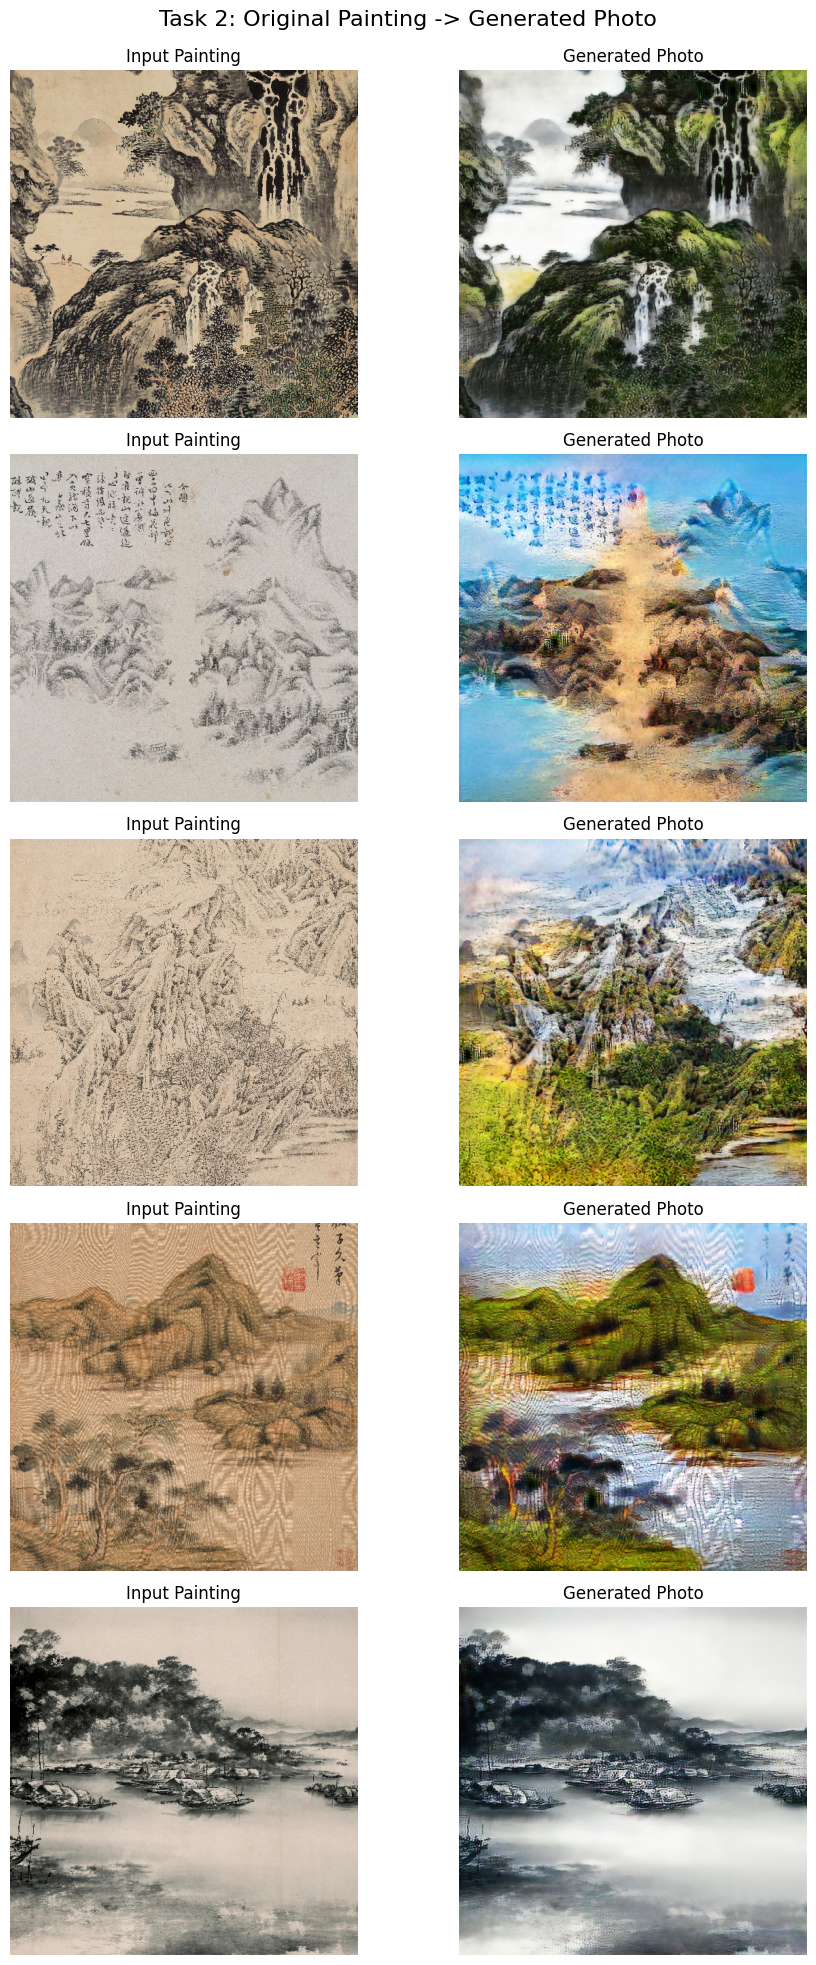

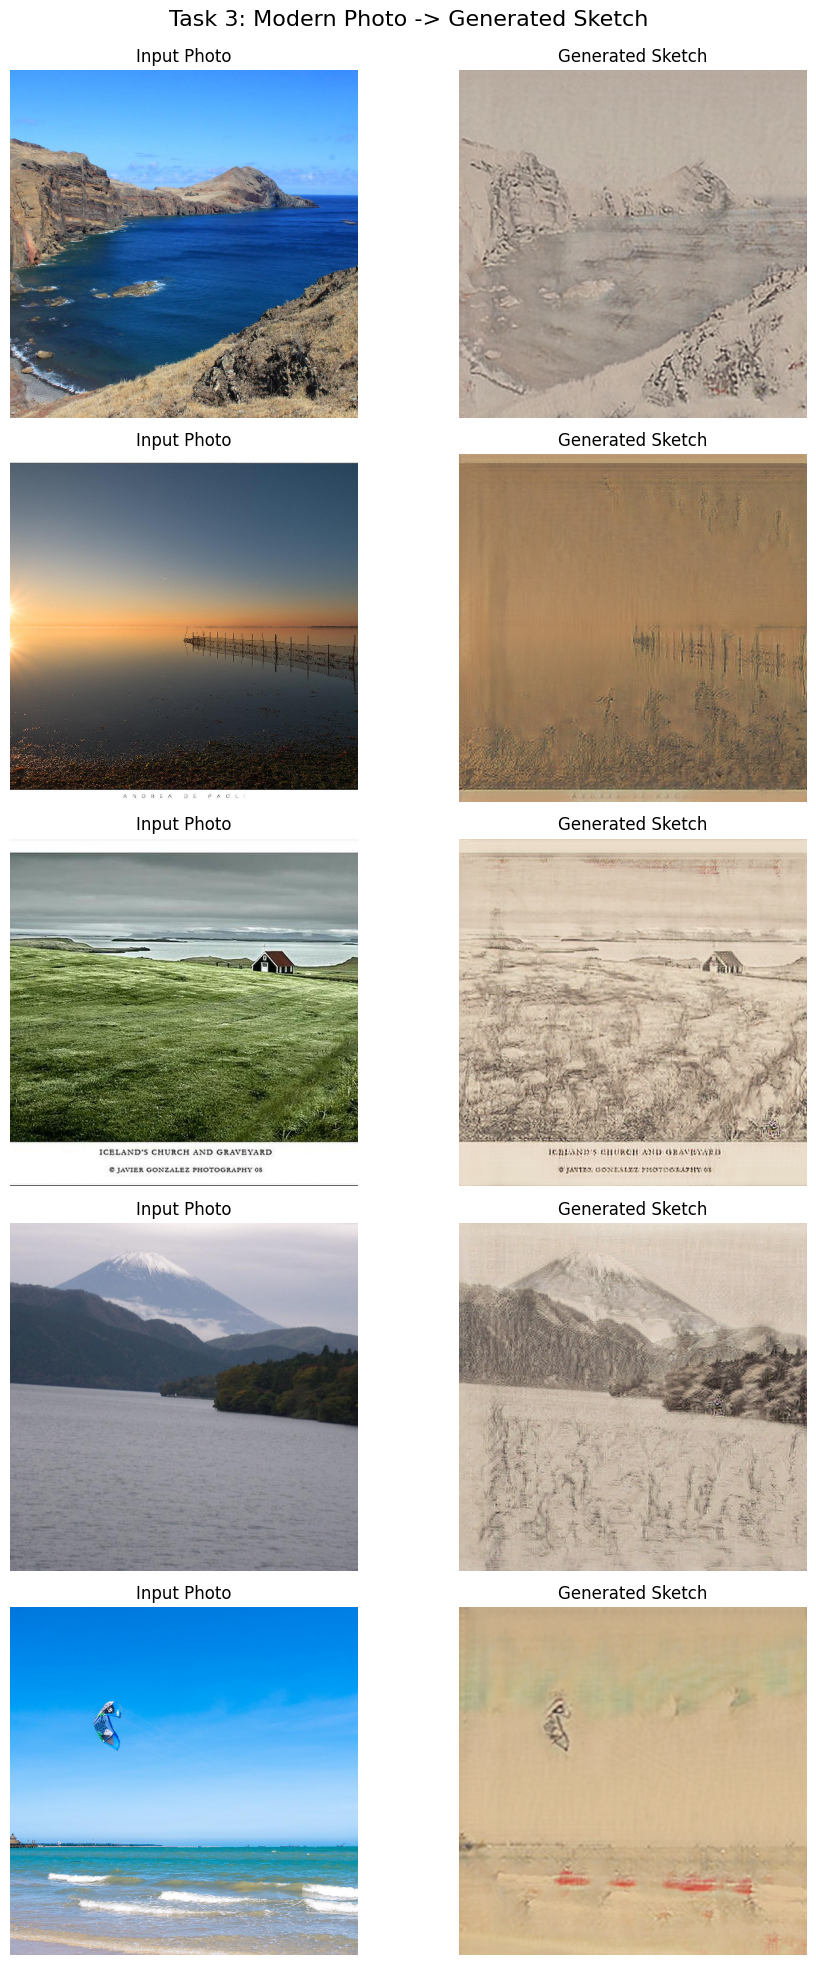

In [ ]:
# Helper function to denormalize images for plotting ([-1, 1] -> [0, 1])
def tensor2im(input_image, imtype=np.uint8):
    if isinstance(input_image, torch.Tensor):
        image_tensor = input_image.data
    else:
        return input_image
    image_numpy = image_tensor[0].cpu().float().numpy()
    if image_numpy.shape[0] == 1:
        image_numpy = np.tile(image_numpy, (3, 1, 1))
    image_numpy = (np.transpose(image_numpy, (1, 2, 0)) + 1) / 2.0 * 255.0
    return image_numpy.astype(imtype)

# 1. Load Data
# We reuse the hidden_test_dataset and loader from your snippet
hidden_loader = DataLoader(hidden_test_dataset, batch_size=5, shuffle=False)
fixed_batch = next(iter(hidden_loader))

# Prepare inputs
val_X = fixed_batch['A'].to(DEVICE) # Paintings
val_Y = fixed_batch['B'].to(DEVICE) # Photos (not used for this specific generation task)

# 2. Prepare Grayscale Version of Input (Task 1)
# Calculate luminance: 0.299*R + 0.587*G + 0.114*B
# Inputs are in [-1, 1], linear combination preserves range roughly
val_X_gray = (val_X[:, 0:1, :, :] * 0.299 + 
              val_X[:, 1:2, :, :] * 0.587 + 
              val_X[:, 2:3, :, :] * 0.114)
# Replicate to 3 channels so netG accepts it
val_X_gray_3c = val_X_gray.repeat(1, 3, 1, 1)

# 3. Inference
netG_loaded.eval()
netG_dlp.eval()
with torch.no_grad():
    # Task 1: B&W Input -> Photo
    generated_from_gray_cycle = netG_loaded(val_X_gray_3c)
    generated_from_gray_dlp = netG_dlp(val_X_gray_3c)
    
    # Task 2: Color Input -> Photo
    generated_from_color_cycle = netG_loaded(val_X)
    generated_from_color_dlp = netG_dlp(val_X)

# 4. Visualization
def plot_results(inputs, outputs, title):
    batch_size = inputs.shape[0]
    fig, axes = plt.subplots(batch_size, 2, figsize=(10, 4 * batch_size))
    plt.suptitle(title, fontsize=16)
    
    for i in range(batch_size):
        # Input
        ax_in = axes[i, 0]
        img_in = tensor2im(inputs[i:i+1])
        ax_in.imshow(img_in)
        ax_in.set_title("Input Painting")
        ax_in.axis('off')
        
        # Output
        ax_out = axes[i, 1]
        img_out = tensor2im(outputs[i:i+1])
        ax_out.imshow(img_out)
        ax_out.set_title("Generated Photo")
        ax_out.axis('off')
    
    plt.tight_layout()
    plt.subplots_adjust(top=0.95)
    plt.show()

# Plot Task 1: Grayscale Input -> Photo
# plot_results(val_X_gray_3c, generated_from_gray, "Task 1: Grayscale Painting -> Generated Photo")

# Plot Task 2: Original Color Input -> Photo
plot_results(val_X, generated_from_color_cycle, "Task 2 (CycleGAN): Original Painting -> Generated Photo")
plot_results(val_X, generated_from_color_dlp, "Task 2 (DLP): Original Painting -> Generated Photo")

# Plot Task 3: Photo -> Sketch
# Ensure netF is in evaluation mode
netF_loaded.eval()
netF_dlp.eval()
with torch.no_grad():
    # val_Y contains the Real Photos from the hidden test set
    # Generate Sketches
    generated_sketches_cycle = netF_loaded(val_Y)
    generated_sketches_dlp = netF_dlp(val_Y)

# Visualization Function (Reused/Adapted)
def plot_photo_to_sketch(inputs, outputs, title):
    batch_size = inputs.shape[0]
    fig, axes = plt.subplots(batch_size, 2, figsize=(10, 4 * batch_size))
    plt.suptitle(title, fontsize=16)
    
    for i in range(batch_size):
        # Input: Modern Photo
        ax_in = axes[i, 0]
        img_in = tensor2im(inputs[i:i+1])
        ax_in.imshow(img_in)
        ax_in.set_title("Input Photo")
        ax_in.axis('off')
        
        # Output: Generated Sketch
        ax_out = axes[i, 1]
        img_out = tensor2im(outputs[i:i+1])
        # Optional: Display sketch in grayscale if preferred, 
        # but tensor2im returns RGB. 
        ax_out.imshow(img_out)
        ax_out.set_title("Generated Sketch")
        ax_out.axis('off')
    
    plt.tight_layout()
    plt.subplots_adjust(top=0.95)
    plt.show()

# Run the plot
plot_photo_to_sketch(val_Y, generated_sketches_cycle, "Task 3 (CycleGAN): Modern Photo -> Generated Sketch")
plot_photo_to_sketch(val_Y, generated_sketches_dlp, "Task 3 (DLP): Modern Photo -> Generated Sketch")
